In [79]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
from pathlib import Path

import adrienParamClassSheared as params
import adrienUtils as utils
importlib.reload(utils)

<module 'adrienUtils' from '/autofs/nccs-svm1_home2/lefauve/git/INCITE/adrien/adrienUtils.py'>

In [80]:
# pick a case
cases = params.generate()
p = cases["R6P1"]

# where you saved slices
slice_dir = Path(p.dirPath) / "2D_slices"
print("slice_dir:", slice_dir)

# the three files you created
paths = {
    "xy": slice_dir / "xy.nc",
    "xz": slice_dir / "xz.nc",
    "yz": slice_dir / "yz.nc",
}
planes_ok = [pl for pl, path in paths.items() if path.exists()]
print("planes_ok:", planes_ok)
for k, v in paths.items():
    print(k, v, "exists:", v.exists())

# buoyancy frequency for this run (needed for Ep and bN)
p.N2 = float(-p.dGrad * p.zAccel)
p.N  = float(np.sqrt(p.N2))

print("N2 =", p.N2)
print("N  =", p.N)

slice_dir: /lustre/orion/cfd135/proj-shared/Hsst/R6P1/001_Final/2D_slices
planes_ok: ['xy', 'xz', 'yz']
xy /lustre/orion/cfd135/proj-shared/Hsst/R6P1/001_Final/2D_slices/xy.nc exists: True
xz /lustre/orion/cfd135/proj-shared/Hsst/R6P1/001_Final/2D_slices/xz.nc exists: True
yz /lustre/orion/cfd135/proj-shared/Hsst/R6P1/001_Final/2D_slices/yz.nc exists: True
N2 = 0.152492
N  = 0.3905022407106008


In [81]:
stats_by_plane = {}

for pl in planes_ok:
    path = paths[pl]
    raw, attrs = utils.read_raw_plane_netcdf(path, copy=True)
    st = utils.plane_stats(raw, p)
    stats_by_plane[pl] = st

    fixed = {"xy":"iz", "xz":"iy", "yz":"ix"}[pl]
    print(f"[{pl}] {fixed}={attrs.get(fixed, '??')}  "
          f"Ek={st['Ek']:.6e}  Ep={st['Ep']:.6e}  "
          f"eps={st['eps_avg']:.6e}  chi={st['chi_avg']:.6e}", flush=True)

# combine (simple mean across the three planes)
stats = {k: float(np.mean([stats_by_plane[pl][k] for pl in stats_by_plane]))
         for k in ["Ek","Ep","eps_avg","chi_avg"]}

print("\n[combined stats from 2D slices]")
for k, v in stats.items():
    print(f"  {k}: {v:.6e}")

Ek_slice = stats["Ek"]
Ek_pct = Ek_slice / p.targKE * 100.0

print(f"2D averaged Ek  is {Ek_pct:.2f}% of 3D average (target)")

[xy] iz=384  Ek=1.782961e-02  Ep=2.273652e-03  eps=3.678998e-03  chi=6.250237e-04
[xz] iy=768  Ek=1.658358e-02  Ep=2.052310e-03  eps=3.249753e-03  chi=5.312742e-04
[yz] ix=1536  Ek=1.579915e-02  Ep=2.004197e-03  eps=3.382008e-03  chi=5.318033e-04

[combined stats from 2D slices]
  Ek: 1.673745e-02
  Ep: 2.110053e-03
  eps_avg: 3.436920e-03
  chi_avg: 5.627004e-04
2D averaged Ek  is 105.99% of 3D average (target)


In [82]:
# --- read all planes ---
raw2d = {}
meta2d = {}
planes_ok = [pl for pl in ["xy", "xz", "yz"] if paths[pl].exists()]
print("planes_ok:", planes_ok)

for pl in planes_ok:
    raw2d[pl], meta2d[pl] = utils._read_plane_nc(paths[pl])
    print(pl, "loaded:", {k: raw2d[pl][k].shape for k in raw2d[pl].keys()})
    
# --- build a SliceBundle 's' containing ONLY derived fields (like get_derived_slices_multi) ---
# We reuse your SliceBundle / VarSlices classes already in adrienUtils.
out_vars = {name: utils.VarSlices(name) for name in ["uN", "vN", "wN", "bN", "epslog", "chilog"]}

Ek = stats["Ek"]
Ep = stats["Ep"]
eps_avg = stats["eps_avg"]
chi_avg = stats["chi_avg"]
N2 = float(p.N2)  # you set this earlier in Cell 5

tiny = 1e-30

for pl in raw2d.keys():
    u2 = raw2d[pl]["u"]
    v2 = raw2d[pl]["v"]
    w2 = raw2d[pl]["w"]
    r2 = raw2d[pl]["r"]
    ee2 = raw2d[pl]["ee"]
    chi2 = raw2d[pl]["chi"]

    out_vars["uN"].set(pl, u2 / np.sqrt(Ek))
    out_vars["vN"].set(pl, v2 / np.sqrt(Ek))
    out_vars["wN"].set(pl, w2 / np.sqrt(Ek))

    out_vars["bN"].set(pl, r2 * (-p.zAccel) / np.sqrt(N2 * Ep))

    with np.errstate(divide="ignore", invalid="ignore"):
        out_vars["epslog"].set(pl, np.log10(np.maximum(ee2, tiny) / eps_avg))
        out_vars["chilog"].set(pl, np.log10(np.maximum(chi2, tiny) / chi_avg))

# idx is not super meaningful here, but keep it for compatibility with plotting funcs
idx_map = {
    "xy": int(meta2d["xy"]["attrs"].get("iz", -1)) if "xy" in meta2d else -1,
    "xz": int(meta2d["xz"]["attrs"].get("iy", -1)) if "xz" in meta2d else -1,
    "yz": int(meta2d["yz"]["attrs"].get("ix", -1)) if "yz" in meta2d else -1,
}

# use any available plane to read stride (they are identical)
first_pl = next(iter(meta2d.keys()))

stride_tuple = (
    int(meta2d[first_pl]["attrs"].get("stride_x", 1)),
    int(meta2d[first_pl]["attrs"].get("stride_y", 1)),
    int(meta2d[first_pl]["attrs"].get("stride_z", 1)),
)

s = utils.SliceBundle(vars=out_vars, idx=idx_map, stride=stride_tuple)

print("planes:", s.available_planes())
print("vars:", s.available_vars())
# Check memory used by notebook
utils.memory_report(globals(), min_gb=0.01)

planes_ok: ['xy', 'xz', 'yz']
xy loaded: {'u': (3072, 1536), 'v': (3072, 1536), 'w': (3072, 1536), 'r': (3072, 1536), 'ee': (3072, 1536), 'chi': (3072, 1536)}
xz loaded: {'u': (3072, 768), 'v': (3072, 768), 'w': (3072, 768), 'r': (3072, 768), 'ee': (3072, 768), 'chi': (3072, 768)}
yz loaded: {'u': (1536, 768), 'v': (1536, 768), 'w': (1536, 768), 'r': (1536, 768), 'ee': (1536, 768), 'chi': (1536, 768)}
planes: ['xy', 'xz', 'yz']
vars: ['uN', 'vN', 'wN', 'bN', 'epslog', 'chilog']
(No NumPy arrays above threshold)

Notebook memory used     :   3.18 GB (  2.5 %)
Remaining available to me: 124.82 GB ( 97.5 %)
Container memory limit   : 128.00 GB
Total node memory        : 503.31 GB


Saved -> figures/R6P1_all_variables_z384_20260202_131907.png
Saved -> figures/R6P1_all_variables_y768_20260202_131911.png
Saved -> figures/R6P1_all_variables_x1536_20260202_131915.png


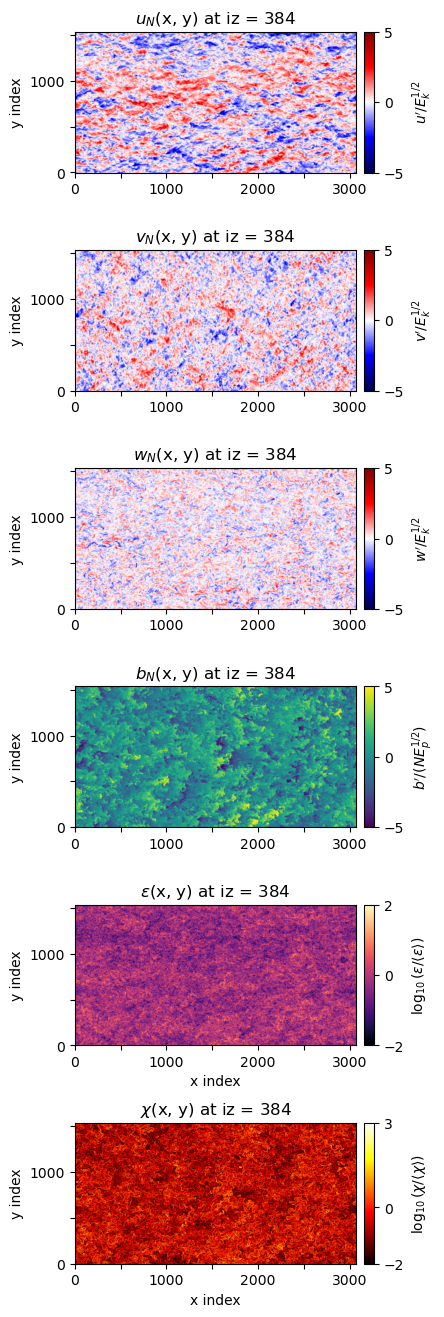

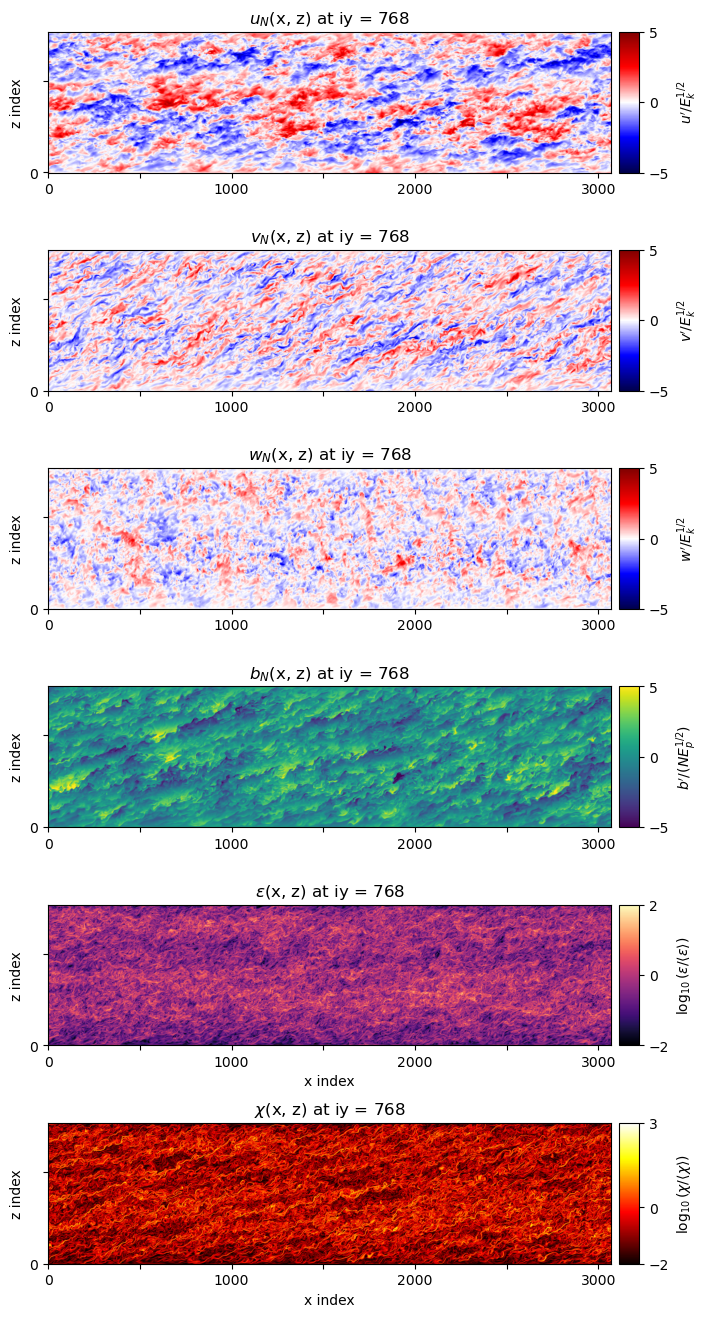

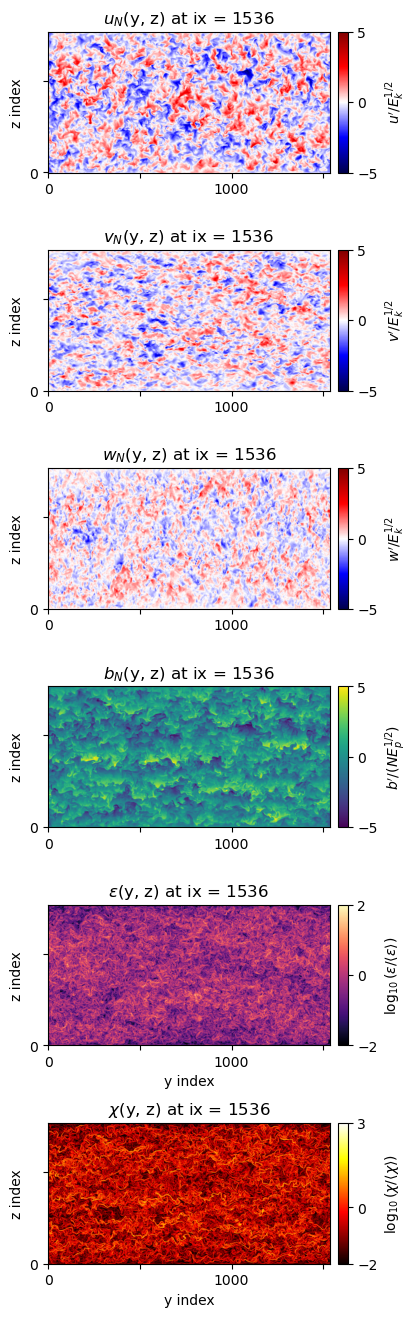

In [83]:
# PLOT A SUMMARY FIGURE FOR EACH SLICE, ALL 6 VARIABLES, AT LOW RESOLUTION 
figs = utils.plot_slices_derived_bundle_multi(
    p, s,
    planes=("xy","xz","yz"),
    save=True, outdir="figures", fmt="png", dpi=300
)

In [84]:
# PLOT FULL RESOLUTION FOR EACH VARIABLE

# stride controls resolution of output (1,1,1 = full res)
stride = (1,1,1)

paths = utils.export_native_resolution_from_bundle_multi(
    p, s,
    planes=("xz","xy","yz"),
    outdir="figures"
)
paths

{'xz': {'u': 'figures/R6P1_u_native_res_y768_20260202_131954.png',
  'v': 'figures/R6P1_v_native_res_y768_20260202_131954.png',
  'w': 'figures/R6P1_w_native_res_y768_20260202_131954.png',
  'b': 'figures/R6P1_b_native_res_y768_20260202_131954.png',
  'e': 'figures/R6P1_e_native_res_y768_20260202_131954.png',
  'c': 'figures/R6P1_c_native_res_y768_20260202_131954.png'},
 'xy': {'u': 'figures/R6P1_u_native_res_z384_20260202_131959.png',
  'v': 'figures/R6P1_v_native_res_z384_20260202_131959.png',
  'w': 'figures/R6P1_w_native_res_z384_20260202_131959.png',
  'b': 'figures/R6P1_b_native_res_z384_20260202_131959.png',
  'e': 'figures/R6P1_e_native_res_z384_20260202_131959.png',
  'c': 'figures/R6P1_c_native_res_z384_20260202_131959.png'},
 'yz': {'u': 'figures/R6P1_u_native_res_x1536_20260202_132011.png',
  'v': 'figures/R6P1_v_native_res_x1536_20260202_132011.png',
  'w': 'figures/R6P1_w_native_res_x1536_20260202_132011.png',
  'b': 'figures/R6P1_b_native_res_x1536_20260202_132011.png',
